# SALT3 Single Spectrum Fitting with Likelihood Scaling & Binning
This notebook load a single supernova spectrum, bins it to a configurable wavelength resolution (e.g. 30 Å) to represent the resolution of the model features, and scales the log-likelihood by the reduced chi-squared $\chi^2_{\text{red}}$ of the best-fit model. This approach accounts for systematic model mismatches and yields physically realistic parameter uncertainties.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sncosmo
import dynesty
import corner
from dynesty import plotting as dyplot
from scipy.optimize import minimize

SPECTRA_DIR = '../data/all_spectra_dereddened'
PARAM_FILE = "../data/cfasnIa_param.dat"
SNID_RESULTS = "../outputs/method_comparison/cfa_SNID_results.csv"
MODEL_NAME = 'salt3'
NLIVE = 300
BIN_WIDTH = 50.0  # Configurable wavelength bin width in Angstroms

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('default')


## 1. Helper Functions

In [2]:
def load_flm_spectrum(file_path):
    data = np.genfromtxt(file_path, invalid_raise=False)
    wave, flux = data[:, 0], data[:, 1]
    err = data[:, 2] if data.shape[1] >= 3 else 0.1 * np.abs(flux)
    mask = np.isfinite(flux) & np.isfinite(err) & (err > 0)
    return wave[mask], flux[mask], err[mask]

def bin_spectrum(wave, flux, err, bin_width=30.0):
    wmin, wmax = 3500.0, 8000.0
    bins = np.arange(wmin, wmax + bin_width, bin_width)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_flux = []
    bin_err = []
    for i in range(len(bins) - 1):
        mask = (wave >= bins[i]) & (wave < bins[i+1])
        if np.any(mask):
            w = 1.0 / err[mask]**2
            flux_mean = np.sum(flux[mask] * w) / np.sum(w)
            err_mean = 1.0 / np.sqrt(np.sum(w))
            bin_flux.append(flux_mean)
            bin_err.append(err_mean)
        else:
            bin_flux.append(0.0)
            bin_err.append(1e10)
    return bin_centers, np.array(bin_flux), np.array(bin_err)

def get_best_fit_chi2_red(wave_b, flux_b, err_b, mjd_obs, redshift):
    model = sncosmo.Model(source=MODEL_NAME)
    if redshift: model.set(z=redshift)
    
    def loss(p):
        t0_offset, x1, c = p
        t0_mjd = mjd_obs - t0_offset * (1 + redshift)
        model.set(t0=t0_mjd, x1=x1, c=c)
        try:
            m_flux_unit = model.flux(mjd_obs, wave_b)
        except:
            return 1e10
        w = 1.0 / err_b**2
        num = np.sum(flux_b * m_flux_unit * w)
        den = np.sum(m_flux_unit**2 * w)
        if den <= 0 or num <= 0: return 1e10
        x0_best = num / den
        chisq = np.sum(((flux_b - x0_best * m_flux_unit) / err_b)**2)
        return chisq
        
    res = minimize(loss, [0.0, 0.0, 0.0], bounds=[(-30, 30), (-4, 4), (-1, 1)], method='L-BFGS-B')
    best_chisq = res.fun
    ndof = len(wave_b) - 3 - 1
    return best_chisq / ndof


In [3]:
def run_fit2(wavelength, flux, flux_err, mjd_obs, nlive, redshift=None):
    # 1. Bin spectrum
    wave_b, flux_b, err_b = bin_spectrum(wavelength, flux, flux_err, bin_width=BIN_WIDTH)

    # 2. Find best-fit chi2_red beforehand using optimization
    chi2_red = get_best_fit_chi2_red(wave_b, flux_b, err_b, mjd_obs, redshift)
    print(f"Pre-fit optimization: Best reduced chi-squared = {chi2_red:.2f}")
    print(f"Scaling log-likelihood by 1 / {chi2_red:.2f}")

    model = sncosmo.Model(source=MODEL_NAME)
    if redshift: model.set(z=redshift)

    # Parameter setup
    params = ['t0', 'x1', 'c']
    priors = {'t0': (-30, 30), 'x1': (-4, 4), 'c': (-1, 1)}

    # Prior transform
    def pt(u):
        t = np.zeros_like(u)
        for i, p in enumerate(params):
            low, high = priors[p]
            t[i] = u[i] * (high - low) + low
        return t

    # Loglikelihood function (scaled)
    def ll(t):
        p_dict = dict(zip(params, t))

        # setting up t0 as an offset
        t0_offset = p_dict.pop('t0')
        t0_mjd = mjd_obs - (t0_offset * (1 + redshift))

        # model setup
        model.set(t0 = t0_mjd)
        model.set(**p_dict)
        model.set(x0=1.0)

        # setup the flux with a x0 of 1
        try:
            m_flux_unit = model.flux(mjd_obs, wave_b)
        except Exception:
            return -1e10

        # setup the weights for the fluxes
        w = 1.0 / err_b**2

        # setting up the numerator and denominator of the weighted least squares minimization
        num, den = np.sum(flux_b * m_flux_unit * w), np.sum(m_flux_unit**2 * w)

        # finding the best x0 scaling parameter
        if den <= 0: return -1e10
        x0_best = num / den
        if x0_best <= 0: return -1e10

        # chisq
        chisq = np.sum(((flux_b - x0_best * m_flux_unit) / err_b)**2)

        # Scale log-likelihood by chi2_red
        loglike = -0.5 * chisq / chi2_red

        return loglike if not np.isnan(loglike) else -1e10

    sampler = dynesty.NestedSampler(ll, pt, len(params), nlive=nlive, sample='rwalk')
    sampler.run_nested()
    return sampler.results, params


## 2. Load Data
Select a spectrum from the `data/all_spectra_dereddened` directory.

Found metadata for sn2000B-20000128.13-fast.flm: z=0.0191, mjd_max=51571.13
True Phase: 8.57 d
SNID Phase: 7.35 d
Subtype: nan


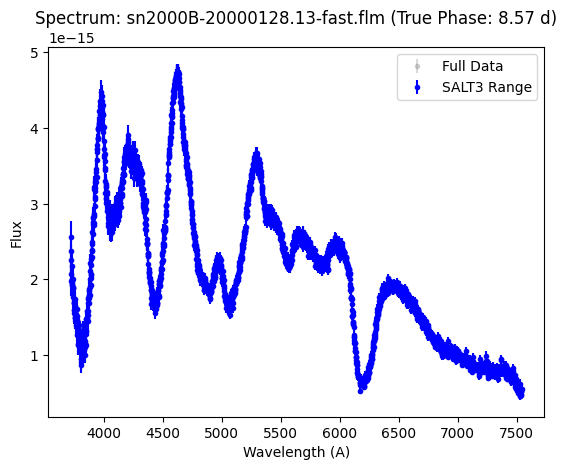

0.0191


In [4]:
# Example file
FILENAME = 'sn2000B-20000128.13-fast.flm'

# Get params from SNID results
true_phase = None
snid_phase = None
mjd_max = None
if os.path.exists(SNID_RESULTS):
    df_snid = pd.read_csv(SNID_RESULTS)
    row = df_snid[df_snid['Filename'] == FILENAME]
    if not row.empty:
        true_phase = row['Age_(days)'].values[0]
        snid_phase = row['bootstrap_age'].values[0]
        subtype = row['Subtype'].values[0]
        mjd_max = row['MJD'].values[0]
        z = row['redshift'].values[0]


if mjd_max is not None:
    print(f"Found metadata for {FILENAME}: z={z}, mjd_max={mjd_max}")
    if true_phase is not None:
        print(f"True Phase: {true_phase:.2f} d")
        print(f"SNID Phase: {snid_phase:.2f} d")
        print(f"Subtype: {subtype}")
    wave, flux, err = load_flm_spectrum(os.path.join(SPECTRA_DIR, FILENAME))
    
    # Apply SALT3 wavelength range mask
    mask = (wave > 3500) & (wave < 8000)
    wave_f, flux_f, err_f = wave[mask], flux[mask], err[mask]
    
    plt.errorbar(wave, flux, yerr=err, fmt='.', color='gray', alpha=0.3, label='Full Data')
    plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='blue', label='SALT3 Range')
    title = f"Spectrum: {FILENAME}"
    if true_phase is not None: title += f" (True Phase: {true_phase:.2f} d)"
    plt.title(title)
    plt.xlabel("Wavelength (A)")
    plt.ylabel("Flux")
    plt.legend()
    plt.show()
else:
    print(f"Error: Metadata for {sn_id} not found in {PARAM_FILE}")

print(z)

## 3. Run Nested Sampling

In [5]:
results, params_names = run_fit2(wave_f, flux_f, err_f, mjd_max, NLIVE, redshift=z)
print("Fit complete.")

Pre-fit optimization: Best reduced chi-squared = 415.98
Scaling log-likelihood by 1 / 415.98


iter: 1 | bound: 0 | nc: 1 | ncall: 301 | eff(%):  0.332 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-  3.341 | dlogz:    inf >  0.309                                                      

iter: 2 | bound: 0 | nc: 1 | ncall: 302 | eff(%):  0.662 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-    nan | dlogz:    inf >  0.309                                                      

iter: 3 | bound: 0 | nc: 1 | ncall: 303 | eff(%):  0.990 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-  3.495 | dlogz:    inf >  0.309                                                      

iter: 4 | bound: 0 | nc: 1 | ncall: 304 | eff(%):  1.316 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-    nan | dlogz:    inf >  0.309                                                      

...

iter: 3392 | +297 | bound: 8 | nc: 1 | ncall: 63353 | eff(%):  5.850 | loglstar:   -inf < -43.029 <    inf | logz: -53.064 +/-  2.553 | dlogz:  0.004 >  0.309                                        

iter: 3392 | +298 | bound: 8 | nc: 1 | ncall: 63354 | eff(%):  5.852 | loglstar:   -inf < -43.026 <    inf | logz: -53.063 +/-  2.553 | dlogz:  0.003 >  0.309                                        

iter: 3392 | +299 | bound: 8 | nc: 1 | ncall: 63355 | eff(%):  5.854 | loglstar:   -inf < -43.023 <    inf | logz: -53.062 +/-  2.553 | dlogz:  0.002 >  0.309                                        

iter: 3392 | +300 | bound: 8 | nc: 1 | ncall: 63356 | eff(%):  5.855 | loglstar:   -inf < -43.004 <    inf | logz: -53.061 +/-  2.553 | dlogz:  0.001 >  0.309                                        

Fit complete.


## 4. Convergence Plots
Check if the evidence has converged and look at the parameter traces.

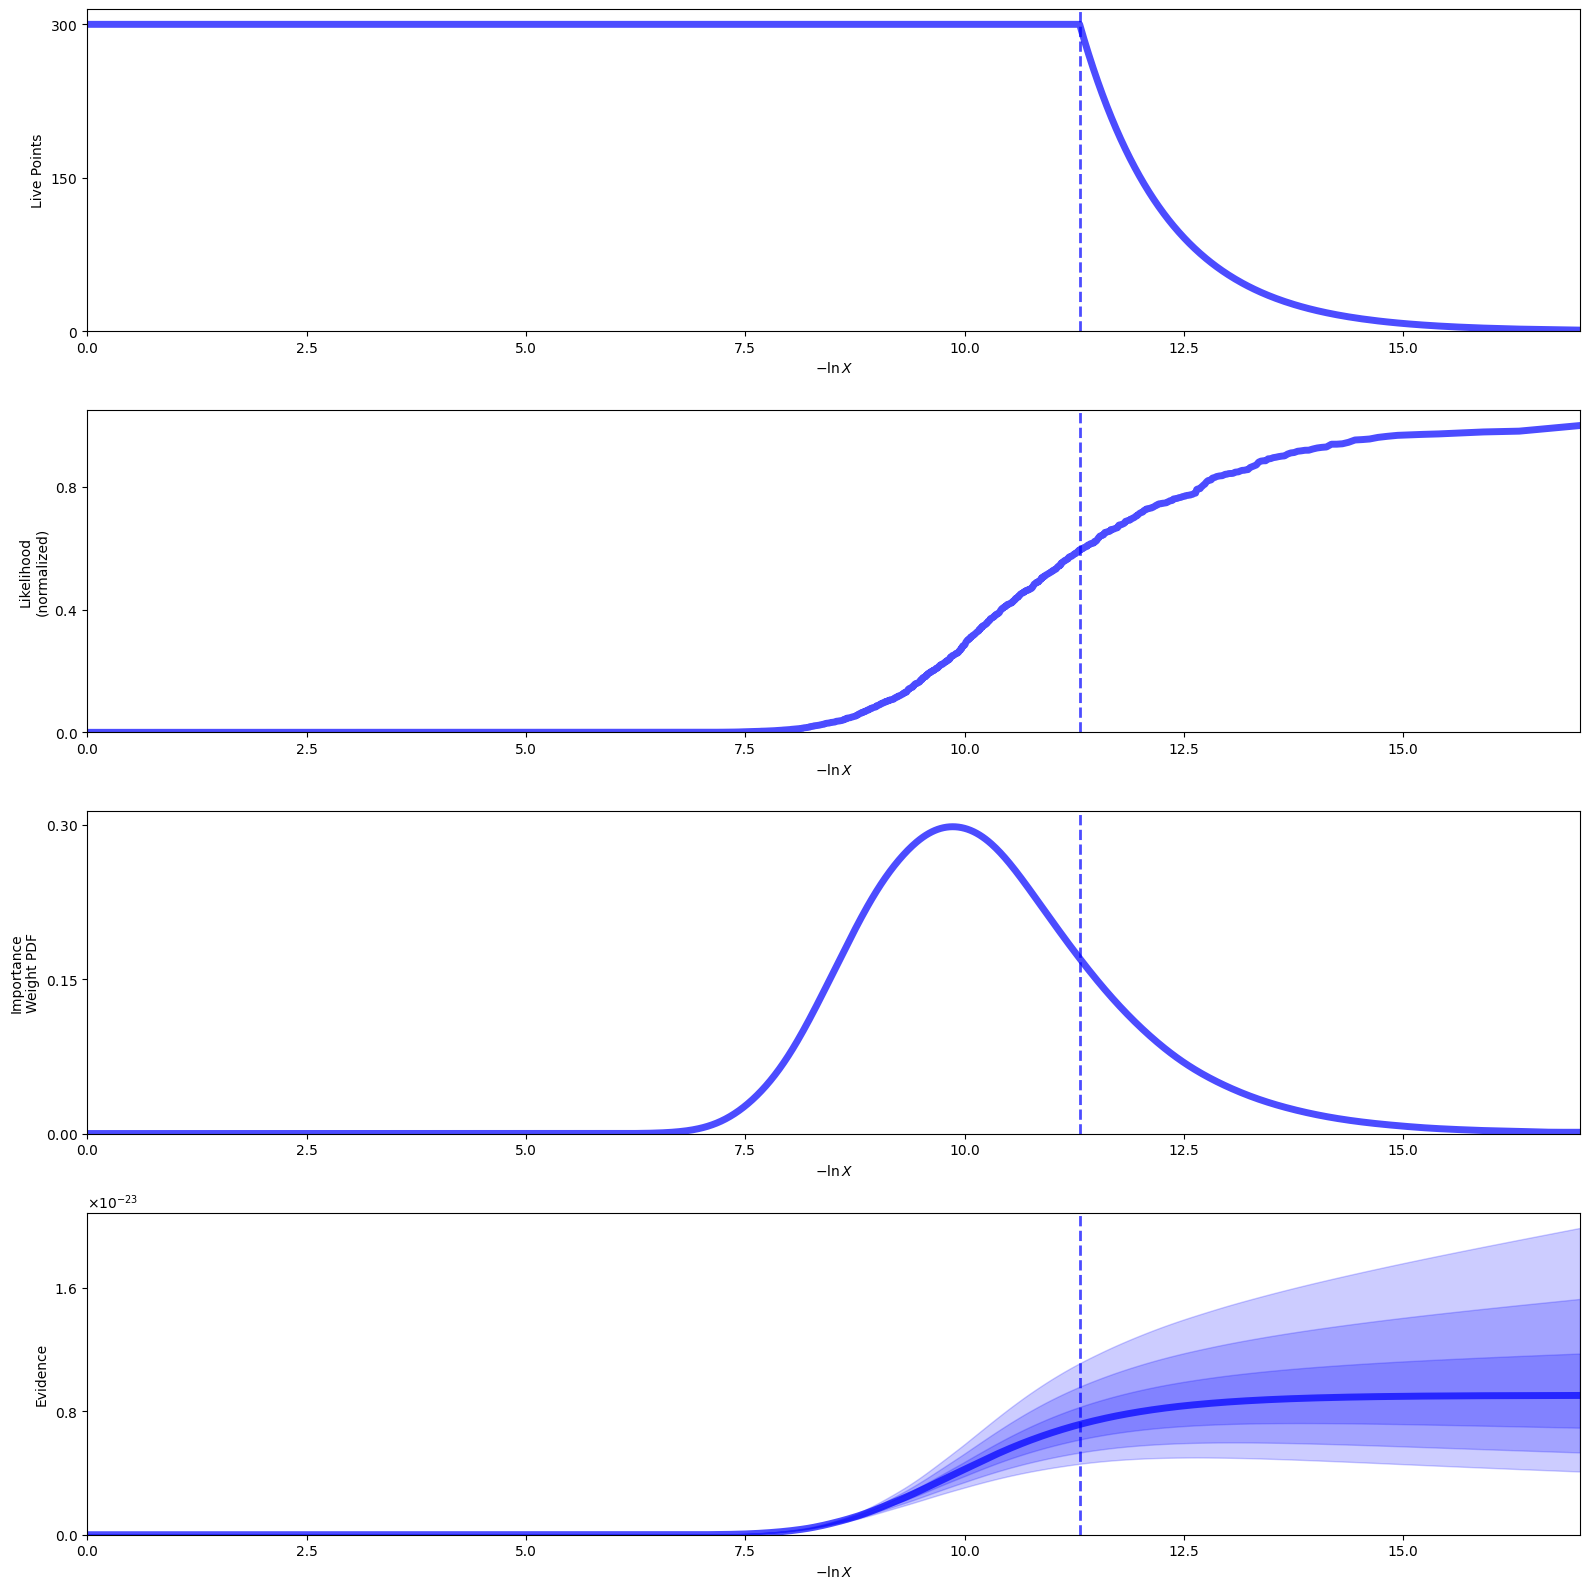

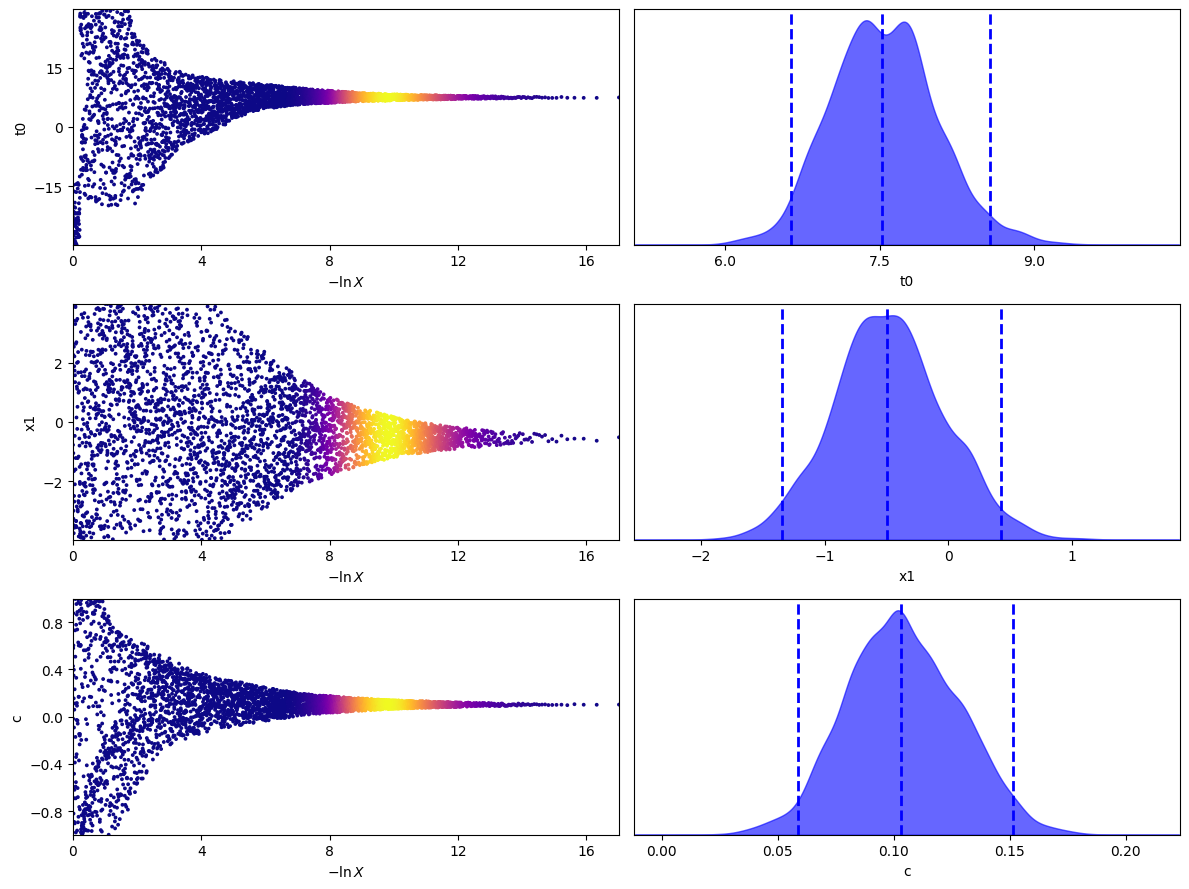

In [6]:
fig, axes = dyplot.runplot(results)
plt.tight_layout()
plt.show()

fig, axes = dyplot.traceplot(results, labels=params_names)
plt.tight_layout()
plt.show()

## 5. Corner Plot
Visualize parameter correlations and marginalized distributions.

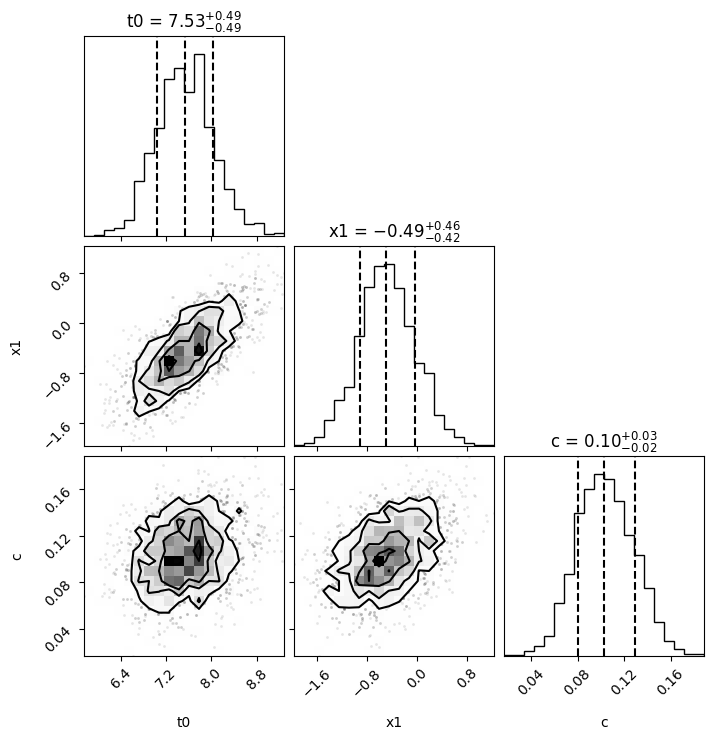

In [7]:
# Resample for equal weights
weights = np.exp(results.logwt - results.logz[-1])
samples = dynesty.utils.resample_equal(results.samples, weights)

fig = corner.corner(samples, labels=params_names, quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()

## 6. Model vs Data
Overlay the best-fit model on the observed spectrum.

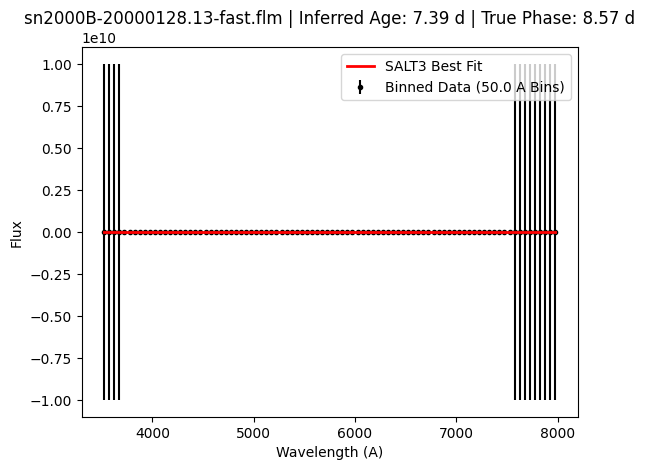

In [8]:
# Get median parameters
med_params = np.median(samples, axis=0)
p_dict = dict(zip(params_names, med_params))

model = sncosmo.Model(source=MODEL_NAME)
model.set(z=z)
model.set(**p_dict)

t0_offset = p_dict['t0']
t0_mjd = mjd_max - t0_offset * (1 + z)   # undo the transform from run_fit2

model.set(t0=t0_mjd)
model.set(x1=p_dict['x1'], c=p_dict['c'])
model.set(x0=1.0)

# Evaluate model on original grid and binned grid
wave_b, flux_b, err_b = bin_spectrum(wave_f, flux_f, err_f, bin_width=BIN_WIDTH)
m_flux_unit = model.flux(mjd_max, wave_f)
m_flux_unit_b = model.flux(mjd_max, wave_b)

# Compute best x0 on binned grid
w_b = 1.0 / err_b**2
x0_best = np.sum(flux_b * m_flux_unit_b * w_b) / np.sum(m_flux_unit_b**2 * w_b)
model.set(x0=x0_best)

model_flux = m_flux_unit * x0_best
model_flux_b = m_flux_unit_b * x0_best

# Plotting on binned grid
plt.errorbar(wave_b, flux_b, yerr=err_b, fmt='.', color='black', label=f'Binned Data ({BIN_WIDTH} A Bins)')
plt.plot(wave_b, model_flux_b, color='red', lw=2, label='SALT3 Best Fit', zorder=10)

inferred_age = (p_dict['t0']) / (1 + z)
plt.title(f"{FILENAME} | Inferred Age: {inferred_age:.2f} d | True Phase: {true_phase:.2f} d" if true_phase is not None else f"{FILENAME} | Inferred Age: {inferred_age:.2f} d")
plt.xlabel("Wavelength (A)")
plt.ylabel("Flux")
plt.legend()
plt.show()


In [9]:
SNID_DIR = '/Users/pxm588@student.bham.ac.uk/Desktop/snid/cfa_pipeline/all_spectra_dereddened_snidded_supersnid'

# The number of the comp file we want to pick
no = '01'

base_filename = FILENAME.rsplit('.', 1)[0]

snid_output_name = f"{base_filename}_comp00{no}_snidflux.dat"

compfile = os.path.join(SNID_DIR, snid_output_name)


compwave, compflux, comperr = load_flm_spectrum(compfile)
mask = (compwave > 3500) & (compwave < 8000)
compwave_f, compflux_f, comperr_f = compwave[mask], compflux[mask], comperr[mask]


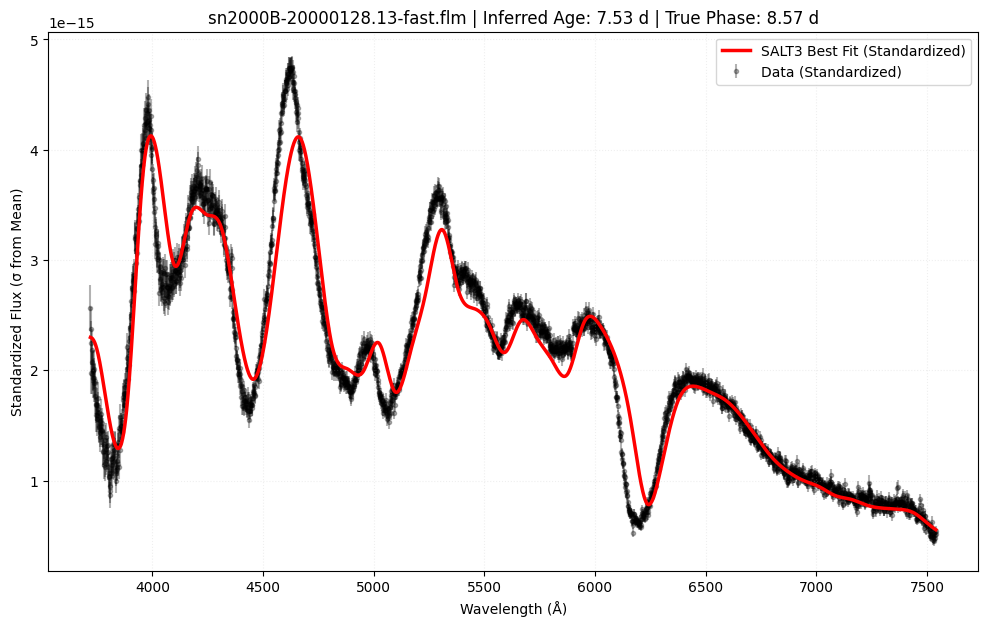

In [10]:
plt.figure(figsize=(12, 7))

# 1. Observed Data (Grey/Black dots)
plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='black',
             alpha=0.3, label='Data (Standardized)', zorder=1)

# 2. SALT3 Model (Bold Red line)
plt.plot(wave_f, model_flux, color='red', lw=2.5,
         label='SALT3 Best Fit (Standardized)', zorder=10)

# # 3. SNID Fit (Blue dots/line)
# plt.errorbar(compwave_f, compflux_f, yerr=comperr_f, fmt='.', color='blue',
#              alpha=0.4, label='Best SNID fit (Standardized)', zorder=5)

# Visual anchors
# plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(alpha=0.2, linestyle=':')

# Metadata and labeling
inferred_age = (p_dict['t0'])
title_str = f"{FILENAME} | Inferred Age: {inferred_age:.2f} d"
if true_phase is not None:
    title_str += f" | True Phase: {true_phase:.2f} d"

plt.title(title_str)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Standardized Flux (σ from Mean)")
plt.legend(loc='upper right', frameon=True)
plt.show()

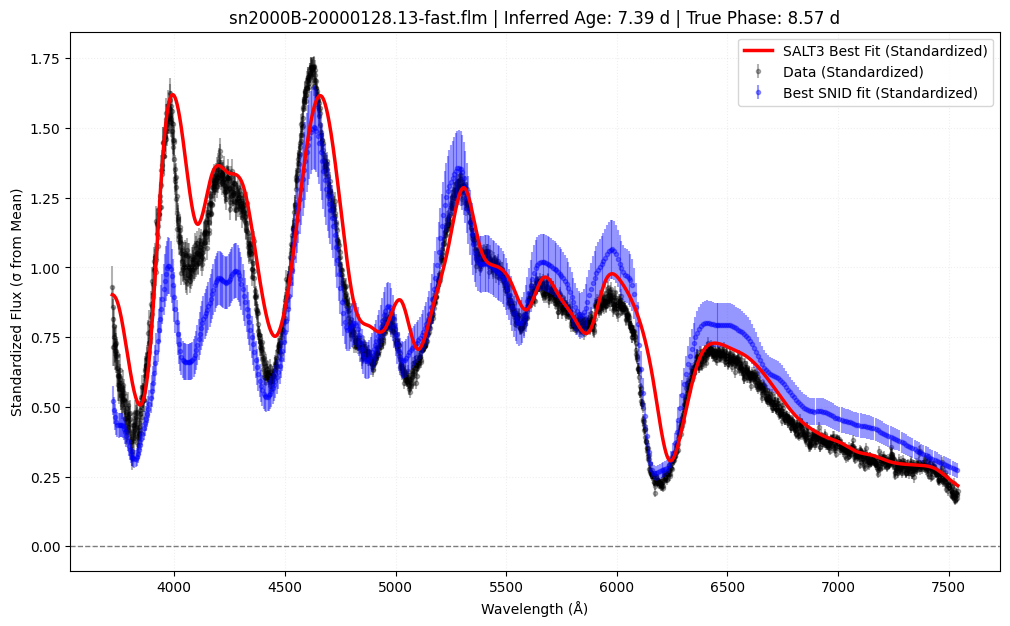

In [11]:
# --- Scalar Normalization (Preserves Continuum & Feature Depth) ---
def normalize_flux(wave, flux, error=None, wmin=5000, wmax=5500):
    """
    Scales the spectrum so the median flux in the chosen wavelength 
    window (wmin to wmax) is exactly 1.0.
    """
    # 1. Create a mask for the anchor window
    mask = (wave >= wmin) & (wave <= wmax)
    
    # Fallback: if the spectrum doesn't cover the window, use the whole array
    if not np.any(mask):
        mask = np.ones(len(wave), dtype=bool)

    # 2. Find the median flux in that window (median ignores noise spikes)
    scale_factor = np.median(flux[mask])

    # 3. Scale the flux
    norm_flux = flux / scale_factor

    if error is not None:
        # Errors must be scaled by the same factor
        norm_error = error / scale_factor
        return norm_flux, norm_error
    
    return norm_flux

# Process all three datasets using the new function
flux_f_norm, err_f_norm = normalize_flux(wave_f, flux_f, err_f)
model_flux_norm = normalize_flux(wave_f, model_flux) # Assuming model uses same wave grid
compflux_f_norm, comperr_f_norm = normalize_flux(compwave_f, compflux_f, comperr_f)
# -----------------------------------------------------------
plt.figure(figsize=(12, 7))

# 1. Observed Data (Grey/Black dots)
plt.errorbar(wave_f, flux_f_norm, yerr=err_f_norm, fmt='.', color='black',
             alpha=0.3, label='Data (Standardized)', zorder=1)

# 2. SALT3 Model (Bold Red line)
plt.plot(wave_f, model_flux_norm, color='red', lw=2.5,
         label='SALT3 Best Fit (Standardized)', zorder=10)

# 3. SNID Fit (Blue dots/line)
plt.errorbar(compwave_f, compflux_f_norm, yerr=comperr_f_norm, fmt='.', color='blue',
             alpha=0.4, label='Best SNID fit (Standardized)', zorder=5)

# Visual anchors
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(alpha=0.2, linestyle=':')

# Metadata and labeling
inferred_age = (p_dict['t0']) / (1 + z)
title_str = f"{FILENAME} | Inferred Age: {inferred_age:.2f} d"
if true_phase is not None:
    title_str += f" | True Phase: {true_phase:.2f} d"

plt.title(title_str)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Standardized Flux (σ from Mean)")
plt.legend(loc='upper right', frameon=True)
plt.show()

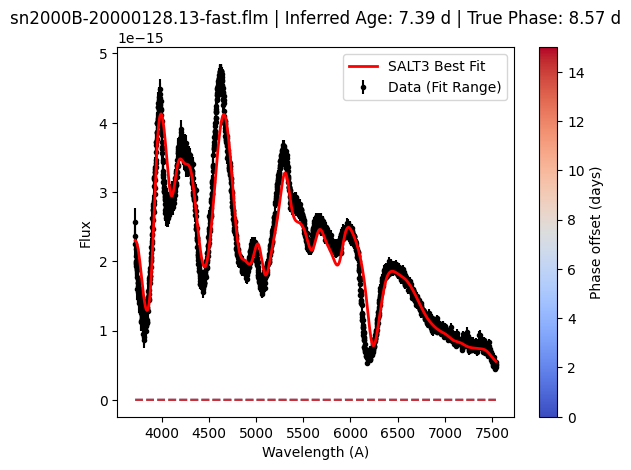

In [12]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

t_values = np.arange(0, 16, 1)
norm = Normalize(vmin=t_values.min(), vmax=t_values.max())
cmap = plt.cm.coolwarm

for t in t_values:
    color = cmap(norm(t))
    plt.plot(wave_f, model.flux(t, wave_f),
             color=color, linestyle='--', alpha=0.5)

plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='black', label='Data (Fit Range)')
plt.plot(wave_f, model_flux, color='red', lw=2, label='SALT3 Best Fit', zorder=10)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label='Phase offset (days)', ax=plt.gca())

inferred_age = (p_dict['t0']) / (1 + z)
plt.title(f"{FILENAME} | Inferred Age: {inferred_age:.2f} d | True Phase: {true_phase:.2f} d" if true_phase is not None else f"{FILENAME} | Inferred Age: {inferred_age:.2f} d")
plt.xlabel("Wavelength (A)")
plt.ylabel("Flux")
plt.legend()
plt.show()